In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

In [3]:
import os 
from sklearn.model_selection import train_test_split 
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential 
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [4]:
data = []
labels = []
classes = 43 
cur_path = os.getcwd() 
for i in range(classes): 
    path = os. path.join(cur_path,'train', str(i)) 
    images = os.listdir(path) 
    for a in images: 
        try: 
            image = Image.open(path + '/' + a) 
            image = image.resize((227,227)) 
            image = np.array(image) 
            data.append(image) 
            labels.append(i) 
        except: 
            print("Error loading image") 
data = np.array(data)
labels = np.array(labels)

In [5]:
print(data.shape, labels.shape)

(39209, 227, 227, 3) (39209,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(31367, 227, 227, 3) (7842, 227, 227, 3) (31367,) (7842,)


In [7]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(227,227,3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    keras.layers.Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3,3), strides=(2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(43, activation='softmax')
])

In [8]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.optimizers.SGD(learning_rate=0.001), metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 55, 55, 96)        34944     
                                                                 
 batch_normalization (BatchN  (None, 55, 55, 96)       384       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 27, 27, 96)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 27, 27, 256)       614656    
                                                                 
 batch_normalization_1 (Batc  (None, 27, 27, 256)      1024      
 hNormalization)                                                 
                                                        

In [9]:
history = model.fit(X_train,y_train,batch_size =64, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
491/491 [==============================] - 2832s 6s/step - loss: 3.1904 - accuracy: 0.2468 - val_loss: 1.8272 - val_accuracy: 0.5068
Epoch 2/10
491/491 [==============================] - 2613s 5s/step - loss: 1.7384 - accuracy: 0.5032 - val_loss: 1.3794 - val_accuracy: 0.5916
Epoch 3/10
491/491 [==============================] - 2526s 5s/step - loss: 1.1698 - accuracy: 0.6523 - val_loss: 1.0447 - val_accuracy: 0.6766
Epoch 4/10
491/491 [==============================] - 2598s 5s/step - loss: 0.8153 - accuracy: 0.7499 - val_loss: 0.4643 - val_accuracy: 0.8725
Epoch 5/10
491/491 [==============================] - 2756s 6s/step - loss: 0.5377 - accuracy: 0.8379 - val_loss: 0.2968 - val_accuracy: 0.9352
Epoch 6/10
491/491 [==============================] - 2550s 5s/step - loss: 0.3828 - accuracy: 0.8853 - val_loss: 0.1787 - val_accuracy: 0.9568
Epoch 7/10
491/491 [==============================] - 2564s 5s/step - loss: 0.2786 - accuracy: 0.9176 - val_loss: 0.1581 - val_accuracy:

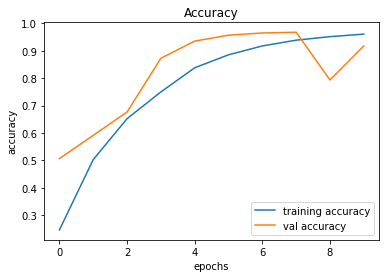

In [10]:
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

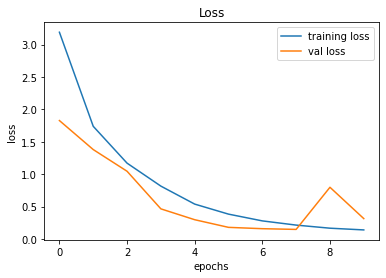

In [11]:
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score
y_test = pd.read_csv('Test.csv')
labels = y_test["ClassId"].values
imgs = y_test["Path"].values
data=[]
for img in imgs:
   image = Image.open(img)
   image = image.resize((227,227))
   data.append(np.array(image))
X_test=np.array(data)
predict_x=model.predict(X_test) 
classes_x=np.argmax(predict_x,axis=1)

In [13]:
from sklearn.metrics import accuracy_score
print(accuracy_score(labels, classes_x))

0.8382422802850357


In [14]:
model.save('traffic_classifier_alexnet.h5')